<a href="https://colab.research.google.com/github/svetazo060510/goit-numpr-hw-12/blob/main/HW12_StremedlovskaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання Тема 12

In [2]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.0 MB/s eta 0:00:00


In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pygad

from sklearn.cluster import SpectralClustering, KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score,
                             homogeneity_score, classification_report)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [50]:
# --- 0. ДОПОМІЖНІ ФУНКЦІЇ ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def align_labels(y_true, y_pred):
    """Вирівнювання міток кластерів для порівняння з реальними класами"""
    if np.mean(y_true == y_pred) < 0.5:
        return 1 - y_pred
    return y_pred

In [33]:
# =================================================================
# 1. ЗАВАНТАЖЕННЯ ТА ПОПЕРЕДНЯ ОБРОБКА
# =================================================================
data = load_breast_cancer()
X, y = data.data, data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Візуалізація попарних розподілів (перші 4 ознаки)...


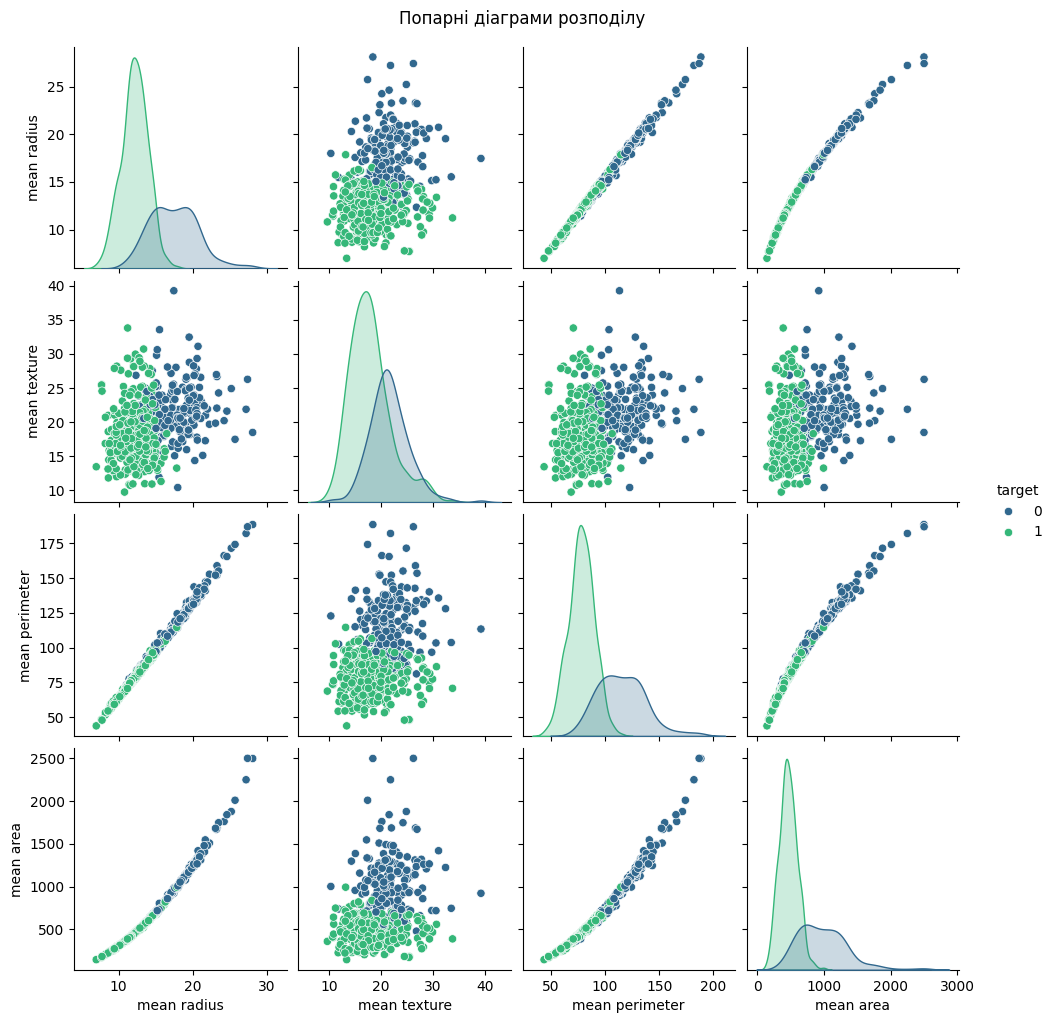

In [51]:
# =================================================================
# 2. EDA: ПОПАРНІ ДІАГРАМИ
# =================================================================
print("Візуалізація попарних розподілів (перші 4 ознаки)...")
df_eda = pd.DataFrame(X[:, :4], columns=data.feature_names[:4])
df_eda['target'] = y
sns.pairplot(df_eda, hue='target', palette='viridis', diag_kind='kde')
plt.suptitle("Попарні діаграми розподілу", y=1.02)
plt.show()

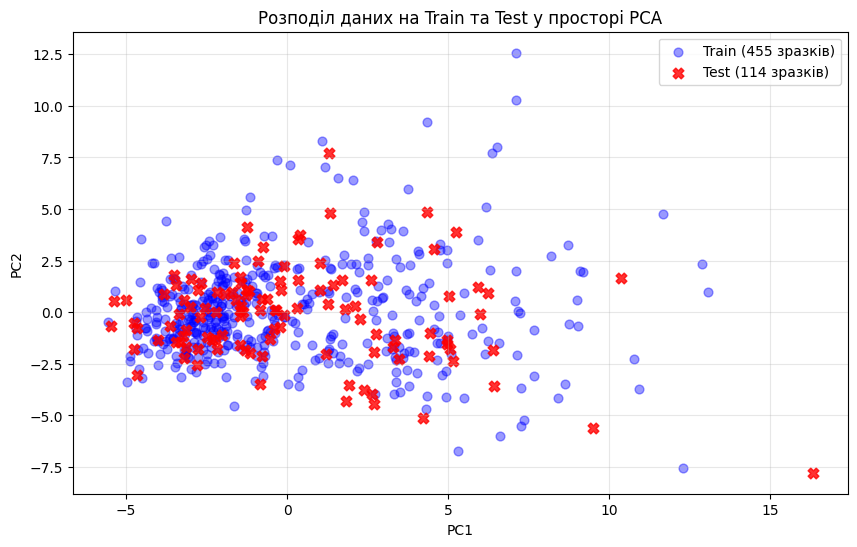

Розмірність X_train: (455, 2) (455 пацієнтів, 2 головні компоненти)


In [52]:
# =================================================================
# 3. PCA ТА РОЗПОДІЛ ДАНИХ
# =================================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42
)

# ВІЗУАЛІЗАЦІЯ РОЗПОДІЛУ TRAIN/TEST
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', alpha=0.4, label=f'Train ({X_train.shape[0]} зразків)', s=40)
plt.scatter(X_test[:, 0], X_test[:, 1], c='red', alpha=0.8, label=f'Test ({X_test.shape[0]} зразків)', marker='X', s=60)
plt.title('Розподіл даних на Train та Test у просторі PCA')
plt.xlabel('PC1'), plt.ylabel('PC2'), plt.legend(), plt.grid(True, alpha=0.3)
plt.show()

print(f"Розмірність X_train: {X_train.shape} (455 пацієнтів, 2 головні компоненти)")

Аналіз розподілу та структури даних:
1. Графік у просторі PCA демонструє ідеальне накладання тестової вибірки (Test Data) на навчальну (Train Data). Це підтверджує, що завдяки використанню стратегії stratify=y, ми зберегли ідентичну структуру розподілу класів у обох наборах. Тестова вибірка є репрезентативною, оскільки вона покриває ті самі області ознакового простору, що й навчальна.
2. Розмірність X_train.shape = (455, 2):
* 455 (Рядки): Це кількість клінічних випадків, відібраних для етапу навчання. Оскільки оригінальний датасет Breast Cancer Wisconsin містить 569 записів, а ми встановили test_size=0.2 (20%), для навчання було виділено рівно 80% даних.
* 2 (Стовпці): Це кількість ознак, отриманих після застосування алгоритму PCA. Ми трансформували складний 30-вимірний простір початкових характеристик клітин (радіус, периметр, увігнутість тощо) у 2 головні компоненти, які акумулюють у собі найбільшу варіативність даних. Це дозволяє нам візуалізувати дані на площині та підвищити ефективність роботи класифікаторів.

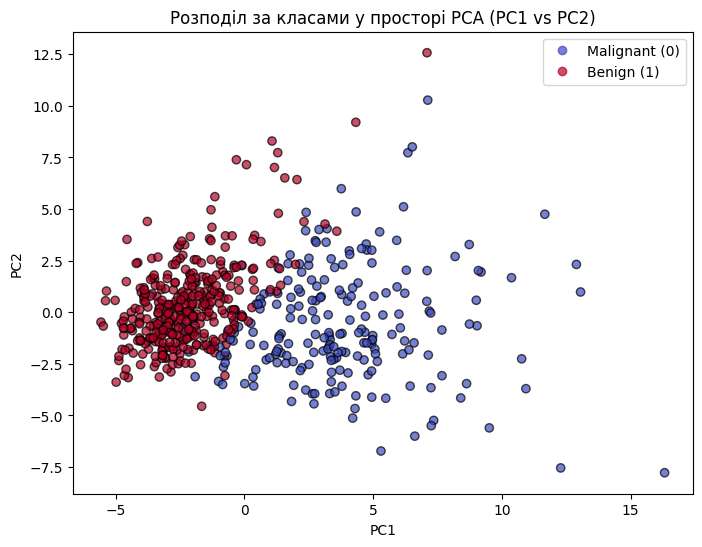

In [53]:
# =================================================================
# 4. ВІЗУАЛІЗАЦІЯ В НОВОМУ ПРОСТОРІ ОЗНАК
# =================================================================
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Розподіл за класами у просторі PCA (PC1 vs PC2)")
plt.xlabel('PC1'), plt.ylabel('PC2')
plt.legend(handles=scatter.legend_elements()[0], labels=["Malignant (0)", "Benign (1)"])
plt.show()


--- Результати кластеризації на X_train ---
   Метод  F1-Score  Homogeneity
 K-Means  0.923599     0.512460
     GMM  0.926655     0.558867
Spectral  0.928196     0.546043


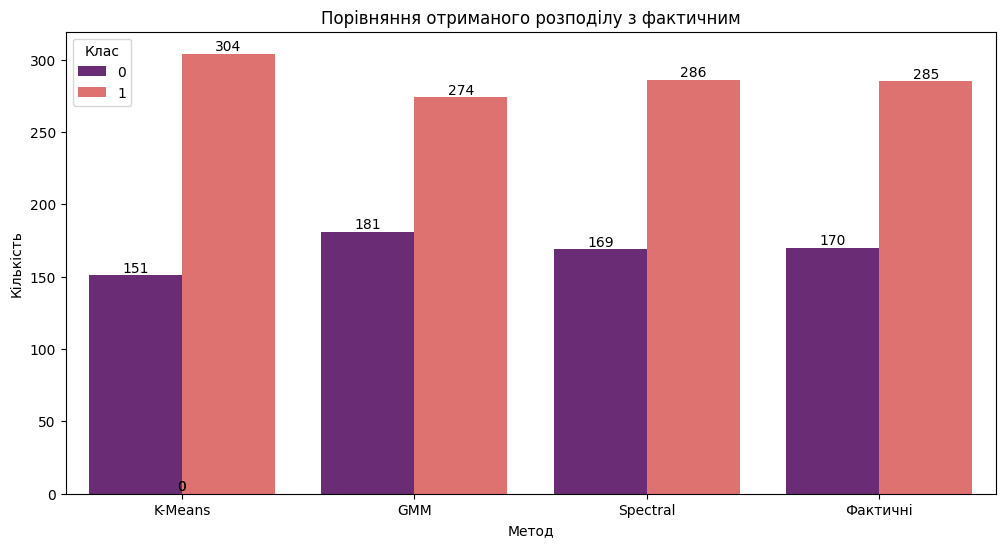

In [54]:
# =================================================================
# 5. КЛАСТЕРИЗАЦІЯ ТА АНАЛІЗ РОЗПОДІЛІВ
# =================================================================
def evaluate_method(y_true, y_pred, name):
    y_aligned = align_labels(y_true, y_pred)
    return {
        "Метод": name,
        "F1-Score": f1_score(y_true, y_aligned),
        "Homogeneity": homogeneity_score(y_true, y_aligned),
        "Labels": y_aligned
    }

# Виконання методів
km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_train)
gmm = GaussianMixture(n_components=2, random_state=42).fit(X_train)
sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)

results_km = evaluate_method(y_train, km.predict(X_train), "K-Means")
results_gmm = evaluate_method(y_train, gmm.predict(X_train), "GMM")
results_sc = evaluate_method(y_train, sc.fit_predict(X_train), "Spectral")

# Таблиця результатів кластеризації
cluster_stats = pd.DataFrame([results_km, results_gmm, results_sc]).drop(columns=['Labels'])
print("\n--- Результати кластеризації на X_train ---")
print(cluster_stats.to_string(index=False))

# ПОРІВНЯЛЬНА ДІАГРАМА РОЗПОДІЛІВ (Кількість об'єктів)
plot_data = []
for res in [results_km, results_gmm, results_sc]:
    counts = pd.Series(res['Labels']).value_counts()
    for label, count in counts.items():
        plot_data.append({'Метод': res['Метод'], 'Клас': label, 'Кількість': count})
# Додаємо фактичні дані
actual_counts = pd.Series(y_train).value_counts()
for label, count in actual_counts.items():
    plot_data.append({'Метод': 'Фактичні', 'Клас': label, 'Кількість': count})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pd.DataFrame(plot_data), x='Метод', y='Кількість', hue='Клас', palette='magma')
plt.title("Порівняння отриманого розподілу з фактичним")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

1. Показник $F1 > 0.92$ для навчання без вчителя є гарним результатом. Це доводить, що структура даних Breast Cancer має дуже чітку фізичну роздільність. Злоякісні та доброякісні клітини суттєво відрізняються за своїми характеристиками.
2. Homogeneity (~0.51 - 0.56): Хоча $F1$ високий, однорідність (Homogeneity) значно нижча. Ця метрика дуже сувора і вона штрафує за наявність навіть кількох "чужих" точок у кластері. Оскільки межа між класами в реальності не є ідеально порожньою (існує "сіра зона"), кластери пересікаються.
3. Порівняння методів: Spectral Clustering став лідером за F1-Score (0.928), що вказує на наявність нелінійних зв'язків у даних, які він вловив найкраще. GMM показав найвищу Homogeneity (0.558), оскільки він моделює кластери як імовірнісні еліпси, що краще відповідає витягнутій формі даних після PCA.

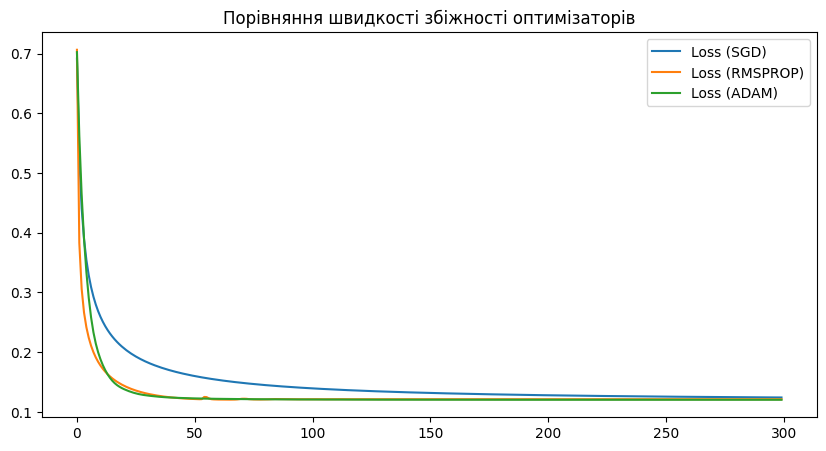

In [55]:
# =================================================================
# 6. КЛАСИФІКАЦІЯ: SKLEARN, ГРАДІЄНТИ ТА GA
# =================================================================

# 6.1 Sklearn Logistic Regression (Baseline)
sk_model = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

# 6.2 Custom Optimizers (SGD, RMSprop, Adam)
class ExpertLogisticRegression:
    def __init__(self, method='adam', lr=0.1, epochs=300):
        self.method, self.lr, self.epochs = method, lr, epochs
        self.weights, self.loss_history = None, []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.random.randn(n) * 0.01
        mt, vt, beta1, beta2, eps = np.zeros(n), np.zeros(n), 0.9, 0.999, 1e-8
        for t in range(1, self.epochs + 1):
            pred = sigmoid(X @ self.weights)
            grad = (1/m) * X.T @ (pred - y)
            loss = -np.mean(y * np.log(pred + eps) + (1 - y) * np.log(1 - pred + eps))
            self.loss_history.append(loss)
            if self.method == 'adam':
                mt = beta1 * mt + (1 - beta1) * grad
                vt = beta2 * vt + (1 - beta2) * (grad**2)
                self.weights -= self.lr * (mt/(1-beta1**t)) / (np.sqrt(vt/(1-beta2**t)) + eps)
            elif self.method == 'rmsprop':
                vt = 0.9 * vt + 0.1 * (grad**2)
                self.weights -= self.lr * grad / (np.sqrt(vt) + eps)
            else: # SGD
                self.weights -= self.lr * grad

    def predict(self, X):
        return (sigmoid(X @ self.weights) >= 0.5).astype(int)

# Навчання та графік Loss
plt.figure(figsize=(10, 5))
custom_models = {}
for m in ['sgd', 'rmsprop', 'adam']:
    model = ExpertLogisticRegression(method=m)
    model.fit(X_train, y_train)
    custom_models[m] = model
    plt.plot(model.loss_history, label=f'Loss ({m.upper()})')
plt.title("Порівняння швидкості збіжності оптимізаторів"), plt.legend(), plt.show()

# 6.3 Генетичний алгоритм (PyGAD)
def fitness_func(ga_instance, solution, solution_idx):
    preds = (sigmoid(X_train @ solution) >= 0.5).astype(int)
    return f1_score(y_train, preds)

ga = pygad.GA(num_generations=100, num_parents_mating=10, fitness_func=fitness_func,
              sol_per_pop=50, num_genes=X_train.shape[1], init_range_low=-2.0,
              init_range_high=2.0, parent_selection_type="sss", keep_parents=2,
              crossover_type="single_point", mutation_type="random",
              mutation_probability=0.1, gene_type=float, random_seed=42)
ga.run()
best_weights, _, _ = ga.best_solution()
y_pred_ga = (sigmoid(X_test @ best_weights) >= 0.5).astype(int)

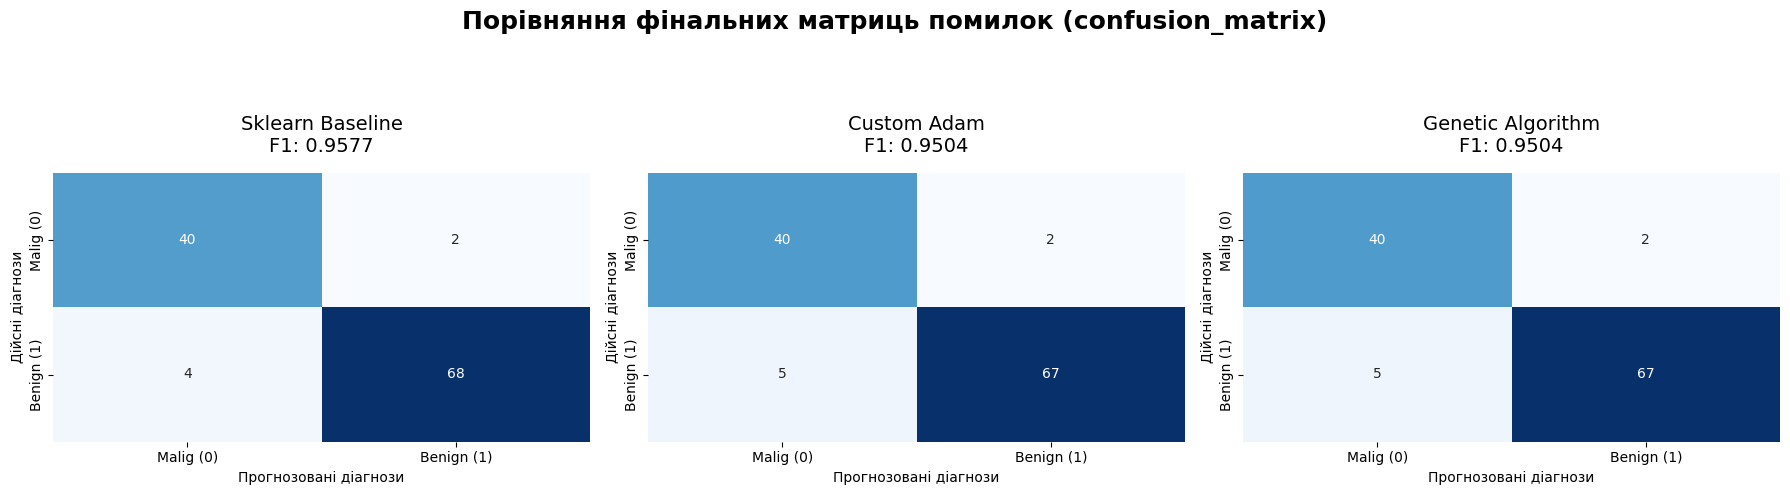


--- ПІДСУМКОВА ТАБЛИЦЯ ЯКОСТІ КЛАСИФІКАЦІЇ ---
            Метод  F1-Score Test
 Sklearn Baseline       0.957746
      Custom Adam       0.950355
Genetic Algorithm       0.950355


In [57]:
# =================================================================
# 7. ФІНАЛЬНА ОЦІНКА ТА MATРИЦІ ПОМИЛОК
# =================================================================
final_models = {
    "Sklearn Baseline": y_pred_sk,
    "Custom Adam": custom_models['adam'].predict(X_test),
    "Genetic Algorithm": y_pred_ga
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
final_stats = []

for i, (name, y_pred) in enumerate(final_models.items()):
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    final_stats.append({"Метод": name, "F1-Score Test": f1})

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Malig (0)', 'Benign (1)'], yticklabels=['Malig (0)', 'Benign (1)'])
    axes[i].set_title(f"{name}\nF1: {f1:.4f}")

    # Індивідуальні заголовки з відступом
    axes[i].set_title(f"{name}\nF1: {f1:.4f}", fontsize=14, pad=15)
    axes[i].set_ylabel('Дійсні діагнози')
    axes[i].set_xlabel('Прогнозовані діагнози')

fig.suptitle("Порівняння фінальних матриць помилок (confusion_matrix)",
             fontsize=18, fontweight='bold', y=0.98)

# Налаштовуємо відступи
fig.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()

# Вивід підсумкової таблиці
print("\n--- ПІДСУМКОВА ТАБЛИЦЯ ЯКОСТІ КЛАСИФІКАЦІЇ ---")
print(pd.DataFrame(final_stats).to_string(index=False))

## Фінальний висновок

1. Усі три підходи продемонстрували відмінні результати з метрикою F1-Score на рівні 0.95 та вище. Це свідчить про те, що обрана модель (логістична регресія) чудово підходить для даного набору даних, а самі класи добре піддаються лінійному розділенню у просторі ознак (особливо після застосування PCA).

2. Реалізація логістичної регресії бібліотека sklearn показала найкращий результат (F1-Score ≈ 0.9577). Це цілком очікувано, оскільки промислові бібліотечні методи використовують високоефективні оптимізовані солвери (наприклад, lbfgs), які мають вбудовані механізми регуляризації та просунуті критерії зупинки. Це дозволяє їм найточніше знаходити оптимальний глобальний мінімум функції втрат.

3. Самостійна реалізація логістичної регресії з оптимізатором Adam досягла дуже високого показника (F1-Score ≈ 0.9503). Хоча результат незначно поступається еталонному з бібліотеки sklearn, проте він доводить, що написаний алгоритм оптимізації з адаптивним кроком навчання успішно зійшовся до правильного рішення. Алгоритм ефективно мінімізував помилку і не застряг на етапі навчання.

4. Генетичний алгоритм показав ідентичний результат до методу Adam (F1-Score ≈ 0.9503). Це підтверджує, що евристичні методи пошуку (без обчислення градієнтів) також здатні знаходити оптимальні ваги для класифікатора. Хоча для стандартної логістичної регресії генетичний алгоритм може бути дещо надлишковим з точки зору обчислювальних ресурсів, він на практиці довів свою абсолютну працездатність, точність та гнучкість в налаштуванні гіперпараметрів.

**Загальний підсумок:**
Оптимізація параметрів моделі як градієнтними (Adam), так і еволюційними (Генетичний алгоритм) методами виконана успішно. Обидва кастомні підходи виявилися конкурентоспроможними та максимально наблизилися до результатів професійної бібліотеки sklearn, що свідчить про правильність математичної логіки та коректність написаного коду.